In [16]:
!python3 --version

Python 3.11.13


In [17]:
!nvidia-smi

Tue Jul 29 10:16:08 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P0             28W /   70W |     651MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [18]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
import tensorflow as tf

from tensorflow import keras

print(tf.__version__)
print(sys.version_info)
for module in mpl, np, pd, sklearn, tf, keras:
    print(module.__name__, module.__version__)


2.18.0
sys.version_info(major=3, minor=11, micro=13, releaselevel='final', serial=0)
matplotlib 3.7.2
numpy 1.26.4
pandas 2.2.3
sklearn 1.2.2
tensorflow 2.18.0
keras._tf_keras.keras 3.8.0


In [19]:
import tensorflow as tf

print(f"TensorFlow Version: {tf.__version__}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Num GPUs Available: {len(gpus)}")

if gpus:
    print(f"GPUs available: {gpus}")
    try:
        # 打印每个GPU的详细信息
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True) # 推荐设置，按需分配显存
            print(f"Details for {gpu.name}:")
            # 可以尝试执行一个小操作来确认
        print("GPU is available and TensorFlow can see it!")

        # 尝试一个简单的GPU运算
        print("\nAttempting a simple computation on GPU...")
        with tf.device('/GPU:0'): # 明确指定在第一个GPU上运行
            a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
            b = tf.constant([[1.0, 2.0], [3.0, 4.0]])
            c = tf.matmul(a, b)
        print("Matrix multiplication result from GPU:")
        print(c.numpy())
        print("If no errors occurred, GPU is working!")

    except RuntimeError as e:
        print(f"RuntimeError during GPU setup or test: {e}")
else:
    print("GPU not available to TensorFlow. TensorFlow will run on CPU.")

TensorFlow Version: 2.18.0
Num GPUs Available: 2
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Details for /physical_device:GPU:0:
Details for /physical_device:GPU:1:
GPU is available and TensorFlow can see it!

Attempting a simple computation on GPU...
Matrix multiplication result from GPU:
[[ 7. 10.]
 [15. 22.]]
If no errors occurred, GPU is working!


In [20]:
#在这个库中，tf帮我们定义很多数据集，这些数据集是以dataset来存储的
# https://tensorflow.google.cn/datasets/catalog/overview
import tensorflow_datasets as tfds

#仍然是电影的二分类问题
#我们可以到数据集中去看imdb_reviews/subwords8k的信息
# with_info if True, tfds.load will return the tuple (tf.data.Dataset, tfds.core.DatasetInfo) 
# containing the info associated with the builder.
# dataset, info = tfds.load('imdb_reviews/subwords8k', with_info = True,
#                           #as_supervised代表有监督的，会把labels，也就是结果返回
#                           as_supervised=True)

# train_dataset, test_dataset = dataset['train'], dataset['test']

# ===========  outdate method above ============


# 1. 加载原始的纯文本数据集
# 注意：我们将 'imdb_reviews/subwords8k' 修改为 'imdb_reviews'
dataset, info = tfds.load('imdb_reviews', with_info=True, as_supervised=True)
train_dataset, test_dataset = dataset['train'], dataset['test']

# 从数据集中分离出文本用于学习词汇表
# dataset.map() 会将函数应用到数据集的每一个元素上
# (text, label) -> text
train_text = train_dataset.map(lambda text, label: text)

# 2. 创建 TextVectorization 分词层
# 为了模拟 'subwords8k'，我们将词汇表大小设置为 8000
VOCAB_SIZE = 8000
encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE
)

# 使用 .adapt() 方法让分词器学习训练数据中的词汇
encoder.adapt(train_text)

# 3. 将分词器应用到整个数据集上
def encode_text(text, label):
  return encoder(text), label

# 使用 .map() 将编码函数应用到训练集和测试集
train_dataset_encoded = train_dataset.map(encode_text)
test_dataset_encoded = test_dataset.map(encode_text)

# 现在 train_dataset_encoded 和 test_dataset_encoded 就是处理好的、
# 可以直接送入模型训练的数据了。
print("数据处理完成！✅")

# 你可以取出一条数据查看效果
for example, label in train_dataset_encoded.take(1):
  print('Encoded text:', example.numpy())
  print('Label:', label.numpy())

数据处理完成！✅
Encoded text: [  11   14   34  412  384   18   90   28    1    8   33 1322 3560   42
  487    1  191   24   85  152   19   11  217  316   28   65  240  214
    8  489   54   65   85  112   96   22 5596   11   93  642  743   11
   18    7   34  394    1  170 2464  408    2   88 1216  137   66  144
   51    2    1 7558   66  245   65 2870   16    1 2860    1    1 1426
 5050    3   40    1 1579   17 3560   14  158   19    4 1216  891    1
    8    4   18   12   14 4059    5   99  146 1241   10  237  704   12
   48   24   93   39   11 7339  152   39 1322    1   50  398   10   96
 1155  851  141    9]
Label: 0


In [21]:
print(f'Vocabulary size: {VOCAB_SIZE}')

# 也可以从 encoder 层中获取词汇列表
vocab = encoder.get_vocabulary()
print(f'Actual vocabulary size learned by encoder: {len(vocab)}')

# 创建一个辅助函数用于解码
def decode_review(encoded_review):
    # 使用 encoder 的词汇表将整数索引映射回单词
    return ' '.join([vocab[i] for i in encoded_review if i > 1]) # 跳过 0(padding) 和 1(unknown)

# 编码一个示例字符串
sample_string = 'Tensorflow is cool.'
encoded_string = encoder([sample_string]) # TextVectorization 层是可调用的
print(f'Encoded string: {encoded_string.numpy()}')

# 解码这个字符串
decoded_string = decode_review(encoded_string.numpy()[0])
print(f'Decoded string: {decoded_string}')

# 看看词汇表中的一些词
print("\nSome tokens in the vocabulary:")
for i in range(20):
    print(f'{i} --> {vocab[i]}')

Vocabulary size: 8000
Actual vocabulary size learned by encoder: 8000
Encoded string: [[  1   7 652]]
Decoded string: is cool

Some tokens in the vocabulary:
0 --> 
1 --> [UNK]
2 --> the
3 --> and
4 --> a
5 --> of
6 --> to
7 --> is
8 --> in
9 --> it
10 --> i
11 --> this
12 --> that
13 --> br
14 --> was
15 --> as
16 --> for
17 --> with
18 --> movie
19 --> but


**词根要包含空格。**

⬆️我们可以看出，空格被考虑在内。

In [22]:
buffer_size = 10000
batch_size = 64

# outdate code
# padded_shapes=tf.compat.v1.data.get_output_shapes(train_dataset)
# padded_shapes_test=tf.compat.v1.data.get_output_shapes(test_dataset)
# print(padded_shapes)
# print(padded_shapes_test)
# train_dataset = train_dataset.shuffle(buffer_size)
#  # padded_batch是每批数据分别做padding
# train_dataset = train_dataset.padded_batch(batch_size,padded_shapes) 
# test_dataset = test_dataset.padded_batch(batch_size,padded_shapes_test)

# 对编码后的数据集进行操作
# .shuffle() 打乱数据
# .padded_batch() 将序列填充到批次内最长序列的长度
train_batches = train_dataset_encoded.shuffle(buffer_size).padded_batch(batch_size)
test_batches = test_dataset_encoded.padded_batch(batch_size)

print("数据批处理和填充完成！✅")

数据批处理和填充完成！✅


In [23]:
embedding_dim = 16

bi_rnn_model = keras.models.Sequential([
    # 添加 InputLayer 来明确指定输入形状
    keras.layers.InputLayer(input_shape=(None,), dtype=tf.int64),

    # Embedding 层的输入维度是词汇表的大小
    keras.layers.Embedding(VOCAB_SIZE, embedding_dim),
    keras.layers.Bidirectional(
        keras.layers.LSTM(units=32, return_sequences=False)
    ),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid'),
])

bi_rnn_model.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

bi_rnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, None, 16)       │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,657 (557.25 KB)

 Trainable params: 142,657 (557.25 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# 使用批处理后的数据进行训练
history = bi_rnn_model.fit(
    train_batches,
    epochs=10,
    validation_data=test_batches # 使用批处理后的测试集
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.5989 - loss: 0.6388 - val_accuracy: 0.8083 - val_loss: 0.4367
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step - accuracy: 0.8663 - loss: 0.3353 - val_accuracy: 0.8665 - val_loss: 0.3383
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step - accuracy: 0.9039 - loss: 0.2576 - val_accuracy: 0.8600 - val_loss: 0.3570
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step - accuracy: 0.8625 - loss: 0.3245 - val_accuracy: 0.8588 - val_loss: 0.3474
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step - accuracy: 0.9337 - loss: 0.1946 - val_accuracy: 0.8591 - val_loss: 0.3605
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step - accuracy: 0.9441 - loss: 0.1678 - val_accuracy: 0.8456 - val_loss: 0.3911
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step - accuracy: 0.9444 - loss: 0.1599 - val_accuracy: 0.8638 - val_loss: 0.4138
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 67ms/step - accuracy: 0.9585 - loss: 0.1258 - 

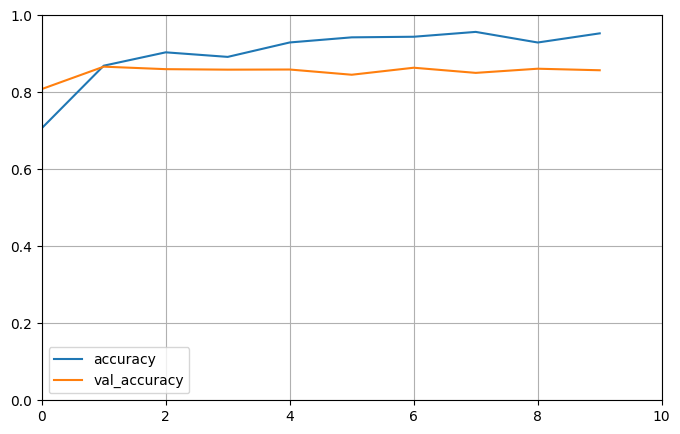

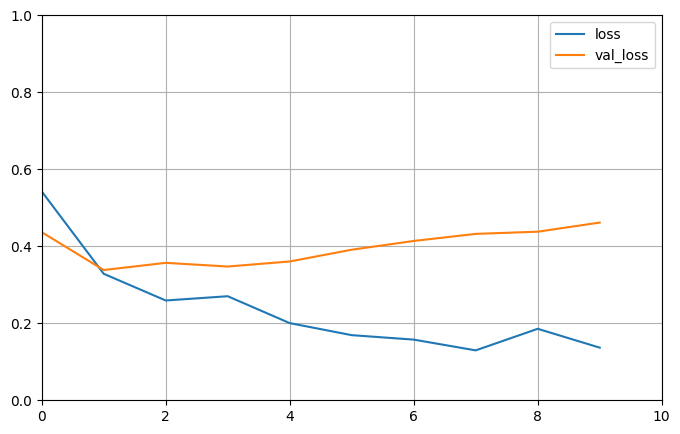

In [25]:
def plot_learning_curves(history, label, epochs, min_value, max_value):
    data = {}
    data[label] = history.history[label]
    data['val_'+label] = history.history['val_'+label]
    pd.DataFrame(data).plot(figsize=(8, 5))
    plt.grid(True)
    plt.axis([0, epochs, min_value, max_value])
    plt.show()
    
plot_learning_curves(history, 'accuracy', 10, 0, 1)
plot_learning_curves(history, 'loss', 10, 0, 1)
#过拟合现象相对之前弱一些

In [26]:
bi_rnn_model.evaluate(test_batches)

391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8592 - loss: 0.4569


[0.4615912437438965, 0.857200026512146]